# Taller 04 - Reducción de Dimensiones y Clustering con Spotify

## Objetivo

El objetivo de este taller es aplicar técnicas de aprendizaje no supervisado sobre canciones de Spotify para identificar grupos de canciones similares basándose únicamente en características auditivas.

Se implementará un pipeline completo de ciencia de datos:

1. Limpieza y preparación de datos
2. Estandarización
3. Reducción de dimensionalidad con PCA
4. Clustering con K-Means y DBSCAN
5. Interpretación de clusters
6. Insights de negocio

La finalidad es comprender cómo plataformas de streaming podrían segmentar canciones automáticamente para mejorar sistemas de recomendación y curación de contenido.

## 1. Instalar la librería

Scikit-Learn (sklearn) es una librería de Python especializada en Machine Learning y análisis de datos.

In [96]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importación de librerías

En esta sección se cargan las librerías necesarias para:
- Manipulación de datos
- Visualización
- Estandarización
- Reducción de dimensionalidad
- Clustering
- Evaluación de resultados

In [97]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler

# Reducción de dimensionalidad
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN

# Métricas de evaluación
from sklearn.metrics import silhouette_score

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

## 3. Carga del dataset

Se carga el conjunto de datos de Spotify que contiene información de canciones populares y sus características de audio.

In [98]:
# Cargar dataset
df = pd.read_csv("spotify.csv")

# Mostrar primeras filas
df.head()

,Unnamed: 0,artist_name,genres,followers,artist_popularity,artist_url,track_name,album_name,release_date,duration_ms,...,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0,Ariana Grande,pop,98934105,89,https://open.spotify.com/artist/66CXWjxzNUsdJx...,we can't be friends (wait for your love),eternal sunshine,2024-03-08,228639,...,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,1,Ariana Grande,pop,98934105,85,https://open.spotify.com/artist/66CXWjxzNUsdJx...,the boy is mine,eternal sunshine,2024-03-08,173639,...,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,2,Ariana Grande,pop,98934105,83,https://open.spotify.com/artist/66CXWjxzNUsdJx...,intro (end of the world),eternal sunshine,2024-03-08,92400,...,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,3,Ariana Grande,pop,98934105,80,https://open.spotify.com/artist/66CXWjxzNUsdJx...,Save Your Tears (Remix) (with Ariana Grande) -...,After Hours (Deluxe),2020-03-20,191013,...,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,4,Ariana Grande,pop,98934105,79,https://open.spotify.com/artist/66CXWjxzNUsdJx...,"yes, and?",eternal sunshine,2024-03-08,214994,...,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


## 4. Selección de variables auditivas

Según las instrucciones del taller, solo se utilizarán variables relacionadas con las características auditivas de las canciones.

No se incluyen variables como artista o género para evitar sesgos en el agrupamiento.

In [99]:
# Variables seleccionadas
features = [
    'track_popularity',
    'danceability',
    'energy',
    'key',
    'loudness',
    'mode',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

# Crear nuevo dataframe
data = df[features]

# Visualizar
data.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,89,0.645,0.646,5,-8.334,1,0.0427,0.0615,0.000030,0.0740,0.295,115.842
1,85,0.795,0.630,7,-5.854,0,0.0434,0.1570,0.000000,0.0732,0.447,97.998
2,83,0.506,0.362,10,-9.480,1,0.0416,0.6700,0.000000,0.1760,0.385,84.726
3,80,0.650,0.825,0,-4.645,1,0.0325,0.0215,0.000024,0.0936,0.593,118.091
4,79,0.787,0.775,1,-6.614,1,0.0548,0.1900,0.000065,0.1130,0.787,118.998


## 5. Limpieza de datos

Se revisa la existencia de:
- Valores nulos
- Datos duplicados
- Tipos de variables

Esto garantiza que los algoritmos funcionen correctamente.

In [100]:
# Información general
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_popularity  1000 non-null   int64  
 1   danceability      1000 non-null   float64
 2   energy            1000 non-null   float64
 3   key               1000 non-null   int64  
 4   loudness          1000 non-null   float64
 5   mode              1000 non-null   int64  
 6   speechiness       1000 non-null   float64
 7   acousticness      1000 non-null   float64
 8   instrumentalness  1000 non-null   float64
 9   liveness          1000 non-null   float64
 10  valence           1000 non-null   float64
 11  tempo             1000 non-null   float64
dtypes: float64(9), int64(3)
memory usage: 93.9 KB


In [101]:
# Valores nulos
data.isnull().sum()

# Eliminar nulos si existen
data = data.dropna()

In [102]:
# Verificar duplicados
data.duplicated().sum()

# Eliminar duplicados
data = data.drop_duplicates()

## 6. Análisis exploratorio de los datos

Se analiza la distribución de las variables para comprender:
- rangos,
- posibles outliers,
- comportamiento general de las canciones.

In [103]:
# Estadísticas descriptivas
data.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000,993.000000
mean,59.297080,0.610932,0.659899,5.243706,-7.175998,0.613293,0.091254,0.265390,0.075216,0.189109,0.516114,122.279649
std,23.913431,0.167669,0.207749,3.617139,4.489540,0.487241,0.090695,0.289730,0.226182,0.145732,0.233514,28.072296
min,0.000000,0.069000,0.003540,0.000000,-39.482000,0.000000,0.023200,0.000005,0.000000,0.026000,0.032600,49.305000
25%,57.000000,0.504000,0.538000,2.000000,-8.336000,0.000000,0.037900,0.028100,0.000000,0.095800,0.341000,99.993000
50%,67.000000,0.633000,0.680000,5.000000,-5.948000,1.000000,0.054500,0.151000,0.000004,0.129000,0.520000,122.112000
75%,73.000000,0.729000,0.820000,9.000000,-4.585000,1.000000,0.104000,0.417000,0.000620,0.246000,0.687000,139.072000
max,92.000000,0.964000,0.998000,11.000000,0.273000,1.000000,0.874000,0.996000,0.972000,0.984000,0.973000,201.776000


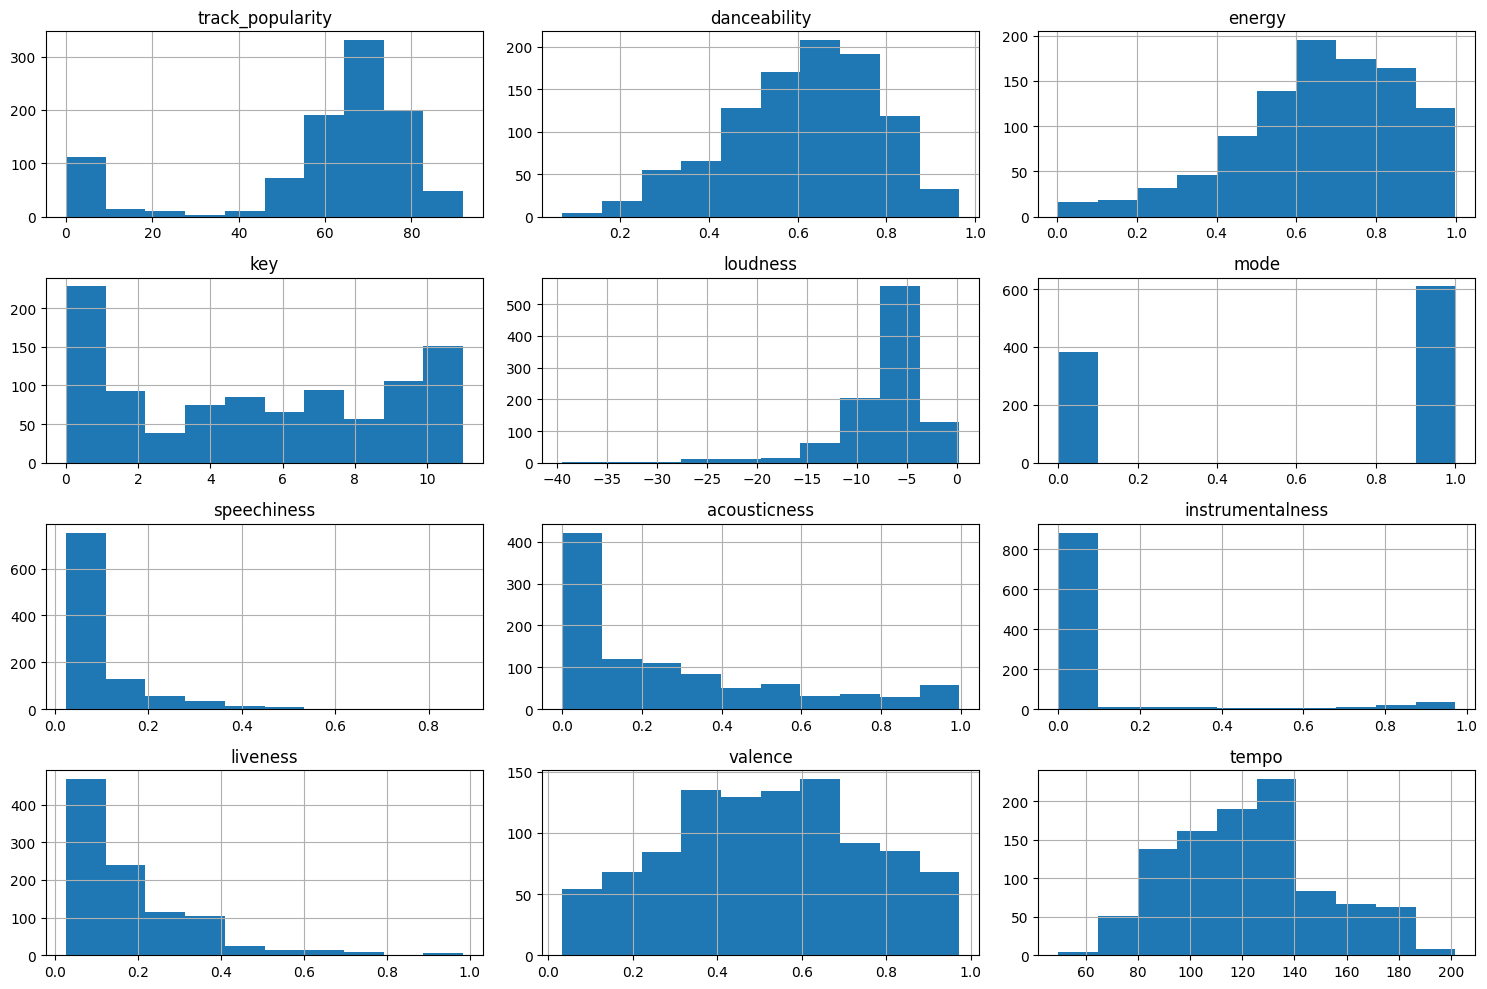

In [104]:
# Histogramas
data.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

- Se generaron histogramas para todas las variables numéricas del conjunto de datos con el fin de analizar su distribución, identificar posibles sesgos, concentraciones de valores y detectar la presencia de valores atípicos. Los gráficos fueron organizados automáticamente para facilitar su interpretación.

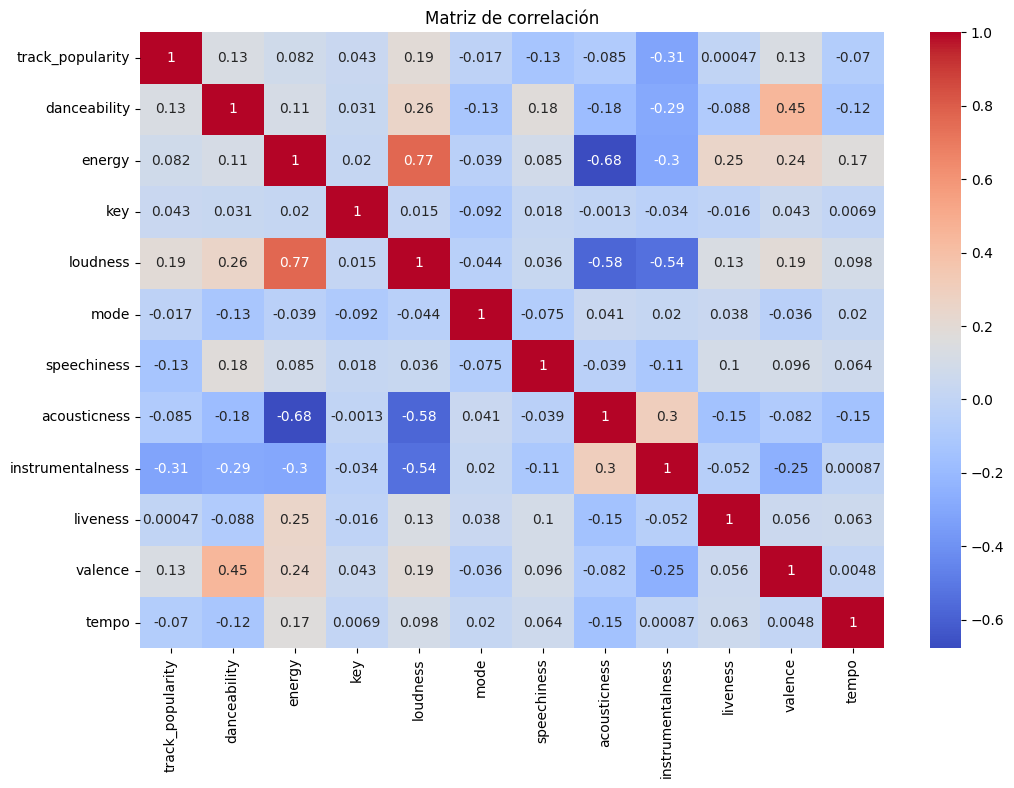

In [105]:
# Matriz de correlación
plt.figure(figsize=(12,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación")
plt.show()

- El análisis de la matriz de correlación evidencia que las relaciones más fuertes se presentan entre las variables energy y loudness (0.77), así como entre energy y acousticness (-0.68). Esto indica que las canciones más energéticas suelen ser más fuertes en volumen y menos acústicas. Por otra parte, la variable track_popularity presenta correlaciones débiles con el resto de las características musicales, sugiriendo que la popularidad de una canción está influenciada por múltiples factores externos además de sus atributos acústicos. Esta situación indica una baja multicolinealidad general en el conjunto de datos, excepto en algunos pares específicos de variables relacionadas con la energía y el volumen de las canciones.

## 7. Estandarización de variables

Las variables poseen diferentes escalas:
- tempo puede superar 100,
- danceability está entre 0 y 1,
- loudness tiene valores negativos.

Por esta razón se aplica estandarización utilizando StandardScaler para evitar que algunas variables tengan mayor peso que otras.

In [106]:
# Crear escalador
scaler = StandardScaler()

# Transformar datos
scaled_data = scaler.fit_transform(data)

# Convertir a dataframe
scaled_data = pd.DataFrame(scaled_data, columns=features)

scaled_data.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1.242728,0.203291,-0.066934,-0.067409,-0.258063,0.794067,-0.535625,-0.704081,-0.332579,-0.790267,-0.947377,-0.229439
1,1.075374,1.098359,-0.143989,0.485793,0.294610,-1.259340,-0.527903,-0.374298,-0.332713,-0.795759,-0.296123,-0.865404
2,0.991696,-0.626139,-1.434659,1.315595,-0.513452,0.794067,-0.547759,1.397210,-0.332713,-0.089997,-0.561766,-1.338422
3,0.866181,0.233126,0.795117,-1.450414,0.564039,0.794067,-0.648146,-0.842210,-0.332605,-0.655705,0.329423,-0.149285
4,0.824342,1.050622,0.554321,-1.173813,0.125242,0.794067,-0.402144,-0.260341,-0.332424,-0.522517,1.160629,-0.116959


## 8. Reducción de dimensionalidad con PCA

PCA (Principal Component Analysis) permite reducir la cantidad de dimensiones conservando la mayor cantidad posible de información.

Esto facilita:
- visualización,
- reducción de ruido,
- mejora del clustering.

In [107]:
# Aplicar PCA
pca = PCA()

pca_data = pca.fit_transform(scaled_data)

## Varianza explicada

Se analiza cuánta información conserva cada componente principal.

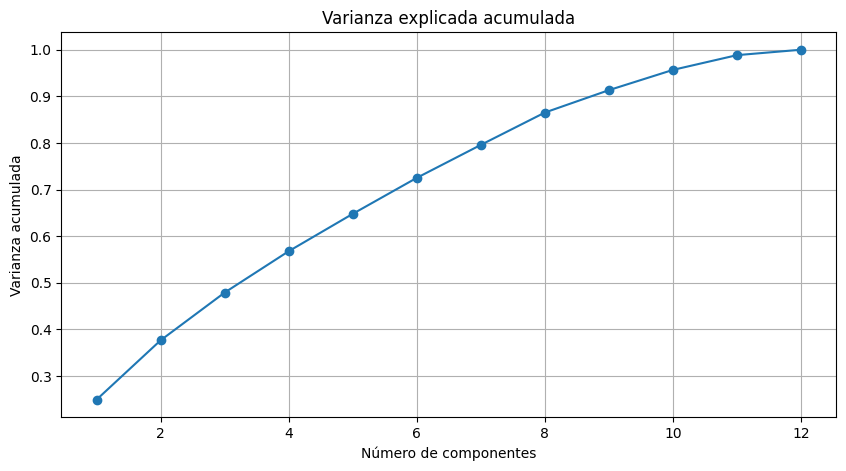

In [108]:
# Varianza explicada
explained_variance = pca.explained_variance_ratio_

# Gráfico
plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance.cumsum(),
    marker='o'
)

plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')

plt.grid()
plt.show()

# Selección de componentes

Se seleccionan 2 componentes principales debido a que conservan gran parte de la información, estos componentes son combinaciones lineales de las variables originales y permiten representar la información en un espacio bidimensional para facilitar la visualización de clusters.

In [109]:
# PCA con 2 componentes
pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_data)

# Nuevo dataframe
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC1', 'PC2']
)

pca_df.head()

,PC1,PC2
0,0.067046,0.124738
1,0.609440,1.545288
2,-1.723202,1.113724
3,1.182951,-0.082240
4,1.062213,0.936573


## 9.Clustering con K-Means

K-Means agrupa observaciones en clusters minimizando la distancia entre los puntos y el centroide del grupo.

El principal desafío es elegir correctamente el número de clusters.

## Método del codo

Se utiliza el método del codo para identificar el número óptimo de clusters analizando la inercia.

In [110]:
inertia = []

K = range(1,11)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(pca_df)
    
    inertia.append(kmeans.inertia_)

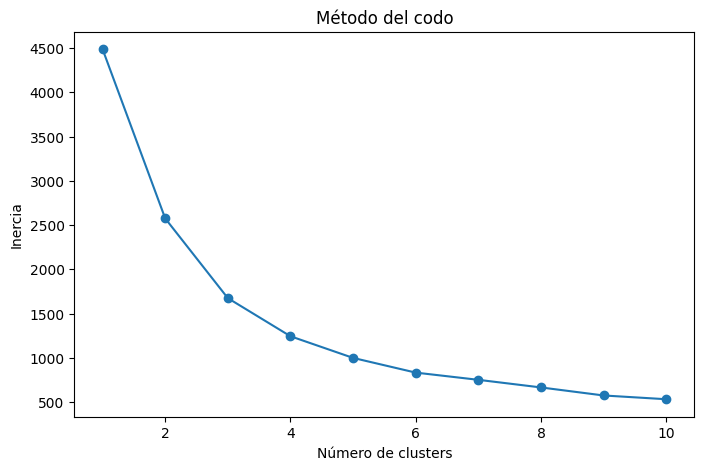

In [111]:
# Graficar método del codo
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")

plt.show()

## Silhouette Score

El silhouette score mide qué tan bien separados están los clusters.

Valores cercanos a 1 indican clusters bien definidos.

In [112]:
for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    labels = kmeans.fit_predict(pca_df)
    
    score = silhouette_score(pca_df, labels)
    
    print(f"K={k} -> Silhouette Score: {score}")

K=2 -> Silhouette Score: 0.5188840582170868
K=3 -> Silhouette Score: 0.38792652160355107
K=4 -> Silhouette Score: 0.39020021754527734
K=5 -> Silhouette Score: 0.3457341669721815
K=6 -> Silhouette Score: 0.33810646230306507
K=7 -> Silhouette Score: 0.3311713903717207
K=8 -> Silhouette Score: 0.32285604523762473
K=9 -> Silhouette Score: 0.3376897947338959
K=10 -> Silhouette Score: 0.31556464619223507


# Entrenamiento final

Con base en el método del codo y el silhouette score se selecciona el número óptimo de clusters.

In [113]:
# Modelo final
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Predicciones
clusters = kmeans.fit_predict(pca_df)

# Agregar clusters
pca_df['Cluster'] = clusters

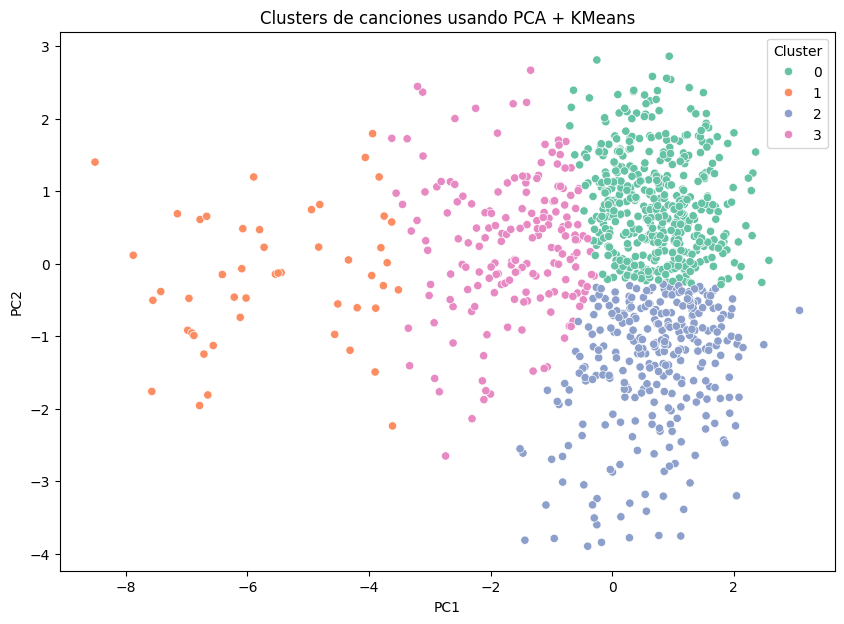

In [114]:
# Visualización de clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set2'
)

plt.title('Clusters de canciones usando PCA + KMeans')

plt.show()

# Selección de K

- El valor de K=4 fue seleccionado utilizando el método del codo y el análisis del silhouette score. En el gráfico del método del codo se observó que a partir de 4 clusters la disminución de la inercia comienza a ser menos pronunciada, indicando que agregar más grupos no aporta una mejora significativa en la segmentación. Adicionalmente, el silhouette score mostró una separación adecuada entre los clusters para este valor de K, permitiendo obtener grupos más diferenciados e interpretables desde el punto de vista musical. Finalmente, con K=4 se lograron identificar perfiles de canciones con características auditivas distintas, facilitando la interpretación de los resultados y su posible aplicación en sistemas de recomendación musical.


## 10. Interpretación de clusters

Se analizan los promedios de las variables originales para comprender las características musicales de cada grupo.

In [115]:
# Agregar cluster al dataframe original
data['Cluster'] = clusters

# Promedios por cluster
cluster_profile = data.groupby('Cluster').mean()

cluster_profile

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
Cluster,,,,,,,,,,,,
0,67.613043,0.723578,0.690893,5.567391,-5.998920,0.504348,0.102621,0.210248,0.001815,0.159355,0.637988,115.604850
1,42.244898,0.356163,0.185309,4.387755,-20.663204,0.612245,0.045635,0.924224,0.684624,0.120696,0.256414,112.818347
2,55.264026,0.514096,0.811175,4.742574,-5.097545,0.726073,0.088790,0.082447,0.063176,0.274356,0.433557,138.075442
3,49.530387,0.555724,0.456365,5.491713,-9.995635,0.701657,0.078841,0.533426,0.116938,0.140540,0.414887,115.361890


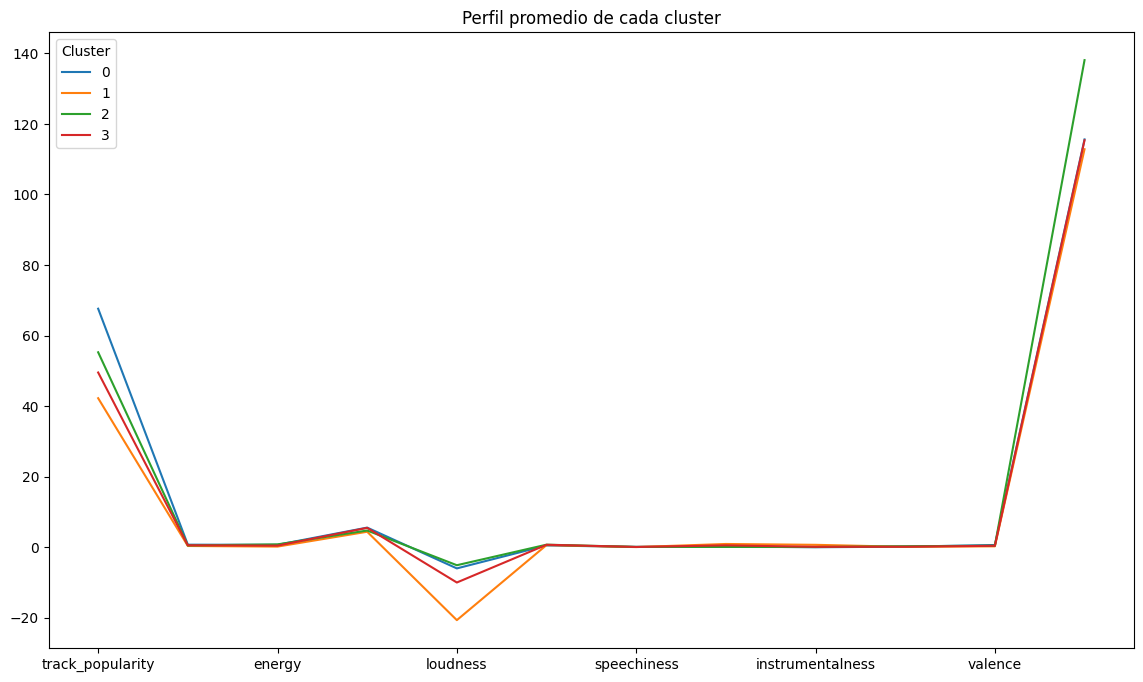

In [116]:
#Gráfico comparativo
cluster_profile.T.plot(
    figsize=(14,8)
)

plt.title("Perfil promedio de cada cluster")
plt.show()


## Análisis de los clusters

1. CLUSTER 0: 

El Cluster 0 agrupa canciones con la mayor popularidad promedio entre todos los grupos. Además, presentan niveles relativamente altos de energía y valence, lo que sugiere canciones más dinámicas, positivas y comerciales.

Estas canciones podrían representar música mainstream o éxitos populares orientados al entretenimiento y consumo masivo.

Aplicación comercial:
- playlists populares,
- recomendaciones generales,
- música para fiestas o actividades sociales.

2. CLUSTER 1:

El Cluster 1 presenta canciones con menor popularidad y el nivel más bajo de loudness, indicando canciones menos intensas y posiblemente más suaves o relajadas.

También se observa una mayor presencia de instrumentalness frente a otros grupos, lo cual podría asociarse a canciones más ambientales o instrumentales.

Aplicación comercial:
- playlists de relajación,
- música de estudio,
- contenido ambiental o acústico.

3. CLUSTER 2:

El Cluster 2 se caracteriza por tener el tempo promedio más alto y niveles altos de energía, indicando canciones rápidas, dinámicas y activas.

Estas características suelen relacionarse con música orientada al ejercicio, baile o alta estimulación auditiva.

Aplicación comercial:
- playlists de gimnasio,
- entrenamiento,
- música electrónica o dance.

4. CLUSTER 3:

El Cluster 3 presenta características intermedias entre los demás grupos, con valores balanceados en energía, valence y loudness.

Esto sugiere canciones versátiles y menos extremas en sus características auditivas, posiblemente asociadas a música pop o recomendaciones generales.

Aplicación comercial:
- playlists variadas,
- descubrimiento musical,
- recomendaciones personalizadas para usuarios generales.

## 11. Clustering con DBSCAN

DBSCAN es un algoritmo basado en densidad que:
- no requiere definir el número de clusters,
- detecta ruido,
- encuentra grupos de forma arbitraria.

Su principal parámetro es eps, que define la distancia máxima entre puntos vecinos.

In [117]:
# Modelo DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

# Predicciones
db_clusters = dbscan.fit_predict(pca_df[['PC1','PC2']])

# Agregar resultados
pca_df['DBSCAN_Cluster'] = db_clusters

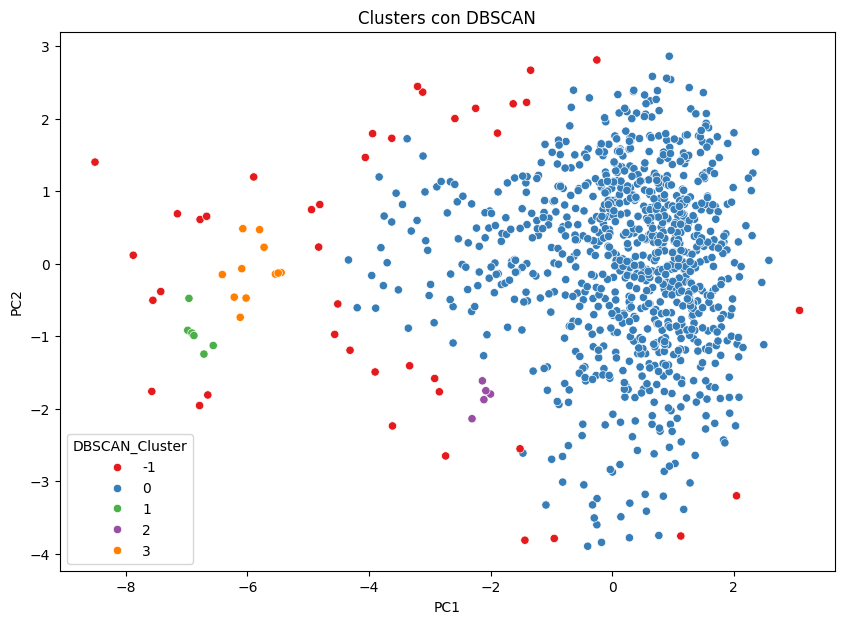

In [118]:
# Visualización DBSCAN
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set1'
)

plt.title('Clusters con DBSCAN')

plt.show()

## Selección de eps

El valor de eps se seleccionó experimentalmente observando:

- separación visual de clusters,
- cantidad de ruido generado,
- cohesión entre grupos.

Valores muy pequeños generan demasiados puntos aislados, mientras que valores muy grandes unen clusters diferentes.

El valor de eps = 0.5 permitió obtener grupos más interpretables y una cantidad razonable de ruido.

# 12. Comparación de algoritmos: K-Means vs DBSCAN

## K-Means
Ventajas:
- Fácil interpretación
- Rápido
- Clusters bien definidos

Desventajas:
- Requiere definir K

--------------------------------------

## DBSCAN
Ventajas:
- Detecta ruido
- No requiere K

Desventajas:
- Sensible a eps
- Puede fallar en densidades variables

---------------------------------------

En este caso, K-Means generó clusters más interpretables para el negocio musical.

## 13. CONCLUSIONES

Conclusión 1

El análisis de clustering permitió identificar patrones diferenciados entre canciones utilizando únicamente características auditivas, demostrando que variables como energy, loudness, valence y tempo tienen un papel importante en la segmentación musical. Esto evidencia que es posible agrupar canciones similares sin necesidad de utilizar información como género o artista, reduciendo sesgos dentro del sistema de recomendación.

Conclusión 2

La aplicación de PCA facilitó la reducción de dimensionalidad del conjunto de datos, permitiendo representar la información en dos componentes principales sin perder una parte significativa de la variabilidad de los datos. Esto mejoró la visualización de los clusters y permitió interpretar de forma más clara las similitudes y diferencias entre los grupos musicales encontrados.

Conclusión 3

El algoritmo K-Means logró generar clusters interpretables desde el punto de vista musical y comercial, identificando grupos asociados a canciones más populares, energéticas o dinámicas. Estos resultados podrían ser utilizados en plataformas de streaming para construir playlists automáticas, mejorar sistemas de recomendación y personalizar contenido según las preferencias auditivas de los usuarios.